# Phân loại Tin giả Tiếng Việt
## Mô hình thực nghiệm: PhoBERT với hàm Loss hiệu chỉnh trọng số
---
### Giới thiệu
Notebook này trình bày quy trình huấn luyện mô hình nhằm phát hiện tin giả trong văn bản tiếng Việt. Trong bài toán này, chúng tôi áp dụng phương pháp hiệu chỉnh hàm Loss để tăng cường khả năng nhận diện tin giả, cụ thể là áp dụng trọng số phạt cao hơn đối với các trường hợp dự đoán sai Tin giả thành Tin thật.

---
## Phần 0 — Cài Đặt Môi Trường & Nhập Thư Viện

In [ ]:
%pip install transformers datasets evaluate accelerate scikit-learn pandas numpy matplotlib seaborn gradio pyvi -q

In [ ]:
import torch

# Kiểm tra tên GPU đang sử dụng
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"✅ Đang sử dụng GPU: {gpu_name}")

    # Hiển thị thông tin chi tiết bằng lệnh hệ thống
else:
    print("❌ Không tìm thấy GPU. Vui lòng vào 'Runtime' -> 'Change runtime type' -> Chọn 'T4 GPU'.")

✅ Đang sử dụng GPU: Tesla T4


In [ ]:
import re, random, warnings, torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
import gradio as gr
from datasets import Dataset

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

print("Thư viện đã sẵn sàng. RANDOM_SEED =", RANDOM_SEED)

Thư viện đã sẵn sàng. RANDOM_SEED = 42


---
## Phần 1 — Tải Dữ Liệu & Phân Chia Train / Validation / Test
Train: 70% | Validation: 15% | Test: 15%

In [ ]:
# ── Tải dữ liệu ────────────────────────────────────────────────────────────
df = pd.read_csv("fakenews_cleaned_full.csv", sep=";", encoding="utf-8-sig")
df = df.dropna(subset=["text_final", "label"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
df["text_final"] = df["text_final"].astype(str)

print(f"Tổng bản ghi: {len(df):,}")
print(f"Phân phối nhãn:\n{df['label'].value_counts().rename({0:'Tin thật (0)', 1:'Tin giả (1)'})}\n")

X = df["text_final"].values
y = df["label"].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED)

print("Kích thước Train:", len(X_train))
print("Kích thước Val:", len(X_val))
print("Kích thước Test:", len(X_test))

# Tạo HuggingFace Datasets
train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
val_dataset = Dataset.from_dict({"text": X_val, "label": y_val})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

Tổng bản ghi: 54,244
Phân phối nhãn:
label
Tin thật (0)    38978
Tin giả (1)     15266
Name: count, dtype: int64

Kích thước Train: 37970
Kích thước Val: 8137
Kích thước Test: 8137


---
## Phần 2 — Khởi tạo Tokenizer cho PhoBERT

In [ ]:
from transformers import AutoTokenizer

model_name = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Chiến lược Head + Tail Truncation: Lấy 128 tokens đầu và 128 tokens cuối
    texts = examples["text"]
    tokenized = tokenizer(texts, add_special_tokens=False, truncation=False)

    input_ids = []
    attention_masks = []

    for ids in tokenized["input_ids"]:
        if len(ids) > 254:
            new_ids = [tokenizer.cls_token_id] + ids[:127] + ids[-127:] + [tokenizer.sep_token_id]
        else:
            new_ids = [tokenizer.cls_token_id] + ids + [tokenizer.sep_token_id]

        padding_length = 256 - len(new_ids)
        mask = [1] * len(new_ids) + [0] * padding_length
        new_ids = new_ids + [tokenizer.pad_token_id] * padding_length

        input_ids.append(new_ids)
        attention_masks.append(mask)

    return {"input_ids": input_ids, "attention_mask": attention_masks}

train_encoded = train_dataset.map(tokenize_function, batched=True)
val_encoded = val_dataset.map(tokenize_function, batched=True)
test_encoded = test_dataset.map(tokenize_function, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/37970 [00:00<?, ? examples/s]

Map:   0%|          | 0/8137 [00:00<?, ? examples/s]

Map:   0%|          | 0/8137 [00:00<?, ? examples/s]

---
## Phần 3 — Thiết Lập Mô Hình & Huấn Luyện

Chúng tôi triển khai **hai kịch bản huấn luyện** để so sánh hiệu quả xử lý mất cân bằng lớp:

| Kịch bản | Hàm Loss | Mô tả |
|---|---|---|
| **Baseline** | Weighted CrossEntropy | Gán trọng số tĩnh: Tin thật=1.0, Tin giả=2.25 |
| **Đề xuất** | Focal Loss (α=0.75, γ=2.0) | Giảm tập trung vào mẫu dễ, tăng trọng số mẫu khó |

**Lý do chọn Focal Loss:** Focal Loss được Lin et al. (2017) giới thiệu, giải quyết hiệu quả hơn Weighted CE khi mô hình đã tự tin với một số mẫu — thay vì chỉ điều chỉnh trọng số tĩnh, Focal Loss động điều chỉnh theo độ khó thực tế của từng mẫu trong quá trình huấn luyện.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import Trainer, TrainingArguments, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# ── 1. Định nghĩa các hàm Loss ──────────────────────────────────────────────

class WeightedCETrainer(Trainer):
    """Baseline: Weighted CrossEntropy với trọng số tĩnh."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Trọng số: Tin thật(0)=1.0, Tin giả(1)=2.25
        weight = torch.tensor([1.0, 2.25], device=logits.device)
        loss_fct = nn.CrossEntropyLoss(weight=weight)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

class FocalLoss(nn.Module):
    """Focal Loss: tập trung vào các mẫu khó phân loại."""
    def __init__(self, alpha=0.75, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss

class FocalLossTrainer(Trainer):
    """Đề xuất: Focal Loss với alpha=0.75, gamma=2.0."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = FocalLoss(alpha=0.75, gamma=2.0)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# ── 2. Hàm đánh giá ─────────────────────────────────────────────────────────
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'f1_macro': f1, 'precision': precision, 'recall': recall}

print("✅ Đã định nghĩa: WeightedCETrainer, FocalLossTrainer, compute_metrics")


✅ Đã định nghĩa: WeightedCETrainer, FocalLossTrainer, compute_metrics


In [ ]:

COMMON_TRAINING_ARGS = dict(
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    fp16=True,
)
print("✅ Cấu hình huấn luyện đã sẵn sàng.")


✅ Cấu hình huấn luyện đã sẵn sàng.


### 3.1 — Huấn Luyện Baseline: Weighted CrossEntropy

In [ ]:
# ── Kịch bản 1: Weighted CrossEntropy (Baseline) ────────────────────────────
model_baseline = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_baseline = TrainingArguments(
    output_dir="./phobert_baseline_results",
    **COMMON_TRAINING_ARGS
)

trainer_baseline = WeightedCETrainer(
    model=model_baseline,
    args=args_baseline,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

print("🚀 Bắt đầu huấn luyện Baseline (Weighted CE)...")
trainer_baseline.train()
print("✅ Huấn luyện Baseline hoàn tất.")


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

🚀 Bắt đầu huấn luyện Baseline (Weighted CE)...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.042885,0.071366,0.989677,0.987145,0.990799,0.983652
2,0.031250,0.052380,0.992749,0.991037,0.990972,0.991103


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.042885,0.071366,0.989677,0.987145,0.990799,0.983652
2,0.031250,0.052380,0.992749,0.991037,0.990972,0.991103
3,0.019394,0.043088,0.994593,0.993306,0.993967,0.992651


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

✅ Huấn luyện Baseline hoàn tất.


### 3.2 — Focal Loss

In [ ]:
# ── Kịch bản 2: Focal Loss  ───────────────────────────────────────
model_focal = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args_focal = TrainingArguments(
    output_dir="./phobert_focal_results",
    **COMMON_TRAINING_ARGS,
    learning_rate=1e-5,
)

trainer_focal = FocalLossTrainer(
    model=model_focal,
    args=args_focal,
    train_dataset=train_encoded,
    eval_dataset=val_encoded,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
)

print("🚀 Bắt đầu huấn luyện Focal Loss...")
trainer_focal.train()
print("✅ Huấn luyện Focal Loss hoàn tất.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

🚀 Bắt đầu huấn luyện Focal Loss...


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision,Recall
1,0.010531,0.012594,0.986482,0.983102,0.988734,0.977842
2,0.005350,0.008592,0.991397,0.989305,0.992131,0.986576
3,0.001673,0.008808,0.992626,0.990828,0.993943,0.987829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

✅ Huấn luyện Focal Loss hoàn tất.


---
## Phần 4 — Đánh Giá & Phân Tích Sâu Kết Quả

Phần này gồm 3 nội dung:
1. **So sánh 2 mô hình** trên tập Test qua bảng và biểu đồ
2. **Confusion Matrix** chi tiết cho từng mô hình
3. **Phân tích lỗi** — các mẫu bị phân loại sai và lý giải nguyên nhân


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ── Đánh giá cả 2 mô hình trên tập Test ─────────────────────────────────────
print("=" * 60)
print("ĐÁNH GIÁ BASELINE (Weighted CrossEntropy)")
print("=" * 60)
preds_baseline = trainer_baseline.predict(test_encoded)
y_pred_baseline = preds_baseline.predictions.argmax(-1)
print(classification_report(y_test, y_pred_baseline, target_names=["Tin thật (0)", "Tin giả (1)"]))

print("\n" + "=" * 60)
print("ĐÁNH GIÁ ĐỀ XUẤT (Focal Loss)")
print("=" * 60)
preds_focal = trainer_focal.predict(test_encoded)
y_pred_focal = preds_focal.predictions.argmax(-1)
print(classification_report(y_test, y_pred_focal, target_names=["Tin thật (0)", "Tin giả (1)"]))


ĐÁNH GIÁ BASELINE (Weighted CrossEntropy)


              precision    recall  f1-score   support

Tin thật (0)       0.99      1.00      1.00      5847
 Tin giả (1)       0.99      0.99      0.99      2290

    accuracy                           0.99      8137
   macro avg       0.99      0.99      0.99      8137
weighted avg       0.99      0.99      0.99      8137


ĐÁNH GIÁ ĐỀ XUẤT (Focal Loss)


              precision    recall  f1-score   support

Tin thật (0)       0.99      1.00      0.99      5847
 Tin giả (1)       0.99      0.98      0.99      2290

    accuracy                           0.99      8137
   macro avg       0.99      0.99      0.99      8137
weighted avg       0.99      0.99      0.99      8137




📊 BẢNG SO SÁNH KẾT QUẢ
               Mô hình Accuracy Precision (macro) Recall (macro) F1-macro F1 Tin giả Recall Tin giả
Weighted CE (Baseline)   0.9942            0.9938         0.9919   0.9928     0.9897         0.9865
  Focal Loss (Đề xuất)   0.9918            0.9927         0.9870   0.9898     0.9852         0.9760


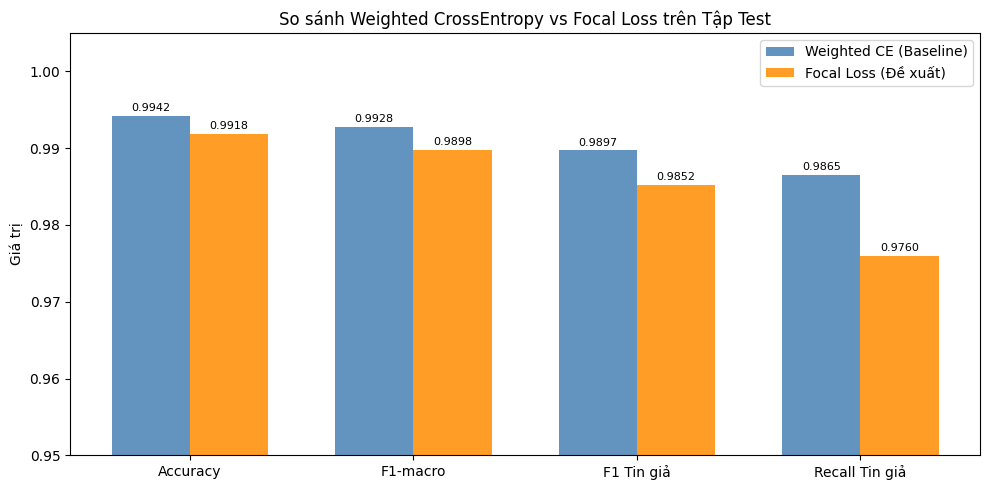

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def get_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    p1, r1, f11, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    return {
        'Mô hình': name,
        'Accuracy': f"{acc:.4f}",
        'Precision (macro)': f"{p:.4f}",
        'Recall (macro)': f"{r:.4f}",
        'F1-macro': f"{f1:.4f}",
        'F1 Tin giả': f"{f11[1]:.4f}",
        'Recall Tin giả': f"{r1[1]:.4f}",
    }

results = pd.DataFrame([
    get_metrics(y_test, y_pred_baseline, "Weighted CE (Baseline)"),
    get_metrics(y_test, y_pred_focal,    "Focal Loss (Đề xuất)"),
])
print("\n📊 BẢNG SO SÁNH KẾT QUẢ")
print(results.to_string(index=False))

# ── Biểu đồ so sánh ─────────────────────────────────────────────────────────
metrics_names = ['Accuracy', 'F1-macro', 'F1 Tin giả', 'Recall Tin giả']
vals_baseline = [float(results.iloc[0][m]) for m in metrics_names]
vals_focal    = [float(results.iloc[1][m]) for m in metrics_names]

x = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, vals_baseline, width, label='Weighted CE (Baseline)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, vals_focal,    width, label='Focal Loss (Đề xuất)',   color='darkorange', alpha=0.85)

ax.set_ylim(0.95, 1.005)
ax.set_ylabel('Giá trị')
ax.set_title('So sánh Weighted CrossEntropy vs Focal Loss trên Tập Test')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.legend()
ax.bar_label(bars1, fmt='%.4f', padding=2, fontsize=8)
ax.bar_label(bars2, fmt='%.4f', padding=2, fontsize=8)
plt.tight_layout()
plt.show()


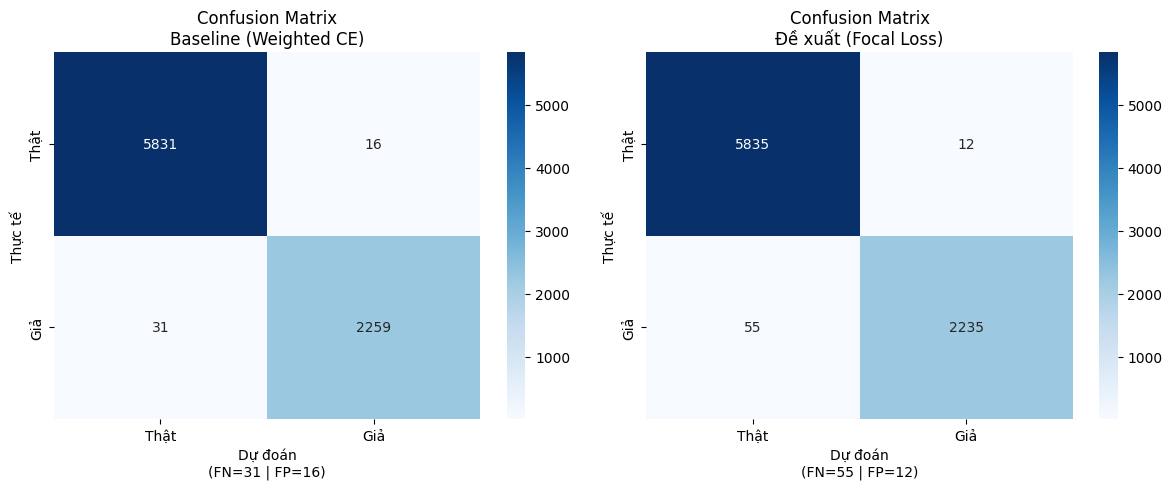

In [ ]:
# ── Confusion Matrix cho 2 mô hình ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_baseline, y_pred_focal],
    ['Baseline (Weighted CE)', 'Đề xuất (Focal Loss)']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Thật', 'Giả'], yticklabels=['Thật', 'Giả'])
    ax.set_title(f'Confusion Matrix\n{title}')
    ax.set_ylabel('Thực tế')
    ax.set_xlabel('Dự đoán')

    # Tính tỉ lệ lỗi
    fn = cm[1][0]  # Tin giả bị dự đoán thành Tin thật
    fp = cm[0][1]  # Tin thật bị dự đoán thành Tin giả
    ax.set_xlabel(f'Dự đoán\n(FN={fn} | FP={fp})')

plt.tight_layout()
plt.show()


### 4.3 — Phân Tích Lỗi Chuyên Sâu cho Weighted CE (Baseline)

In [ ]:
# ── Phân tích lỗi: Weighted CE (Baseline) model ─────────────────────────
X_test_texts = list(X_test)

# Tìm các mẫu sai của Baseline
error_mask_baseline = y_pred_baseline != y_test
error_texts_baseline  = [X_test_texts[i] for i in range(len(y_test)) if error_mask_baseline[i]]
error_true_baseline   = [y_test[i]       for i in range(len(y_test)) if error_mask_baseline[i]]
error_pred_baseline   = [y_pred_baseline[i] for i in range(len(y_test)) if error_mask_baseline[i]]
error_probs_baseline  = preds_baseline.predictions[error_mask_baseline]

label_name = {0: 'Tin thật', 1: 'Tin giả'}

print(f"📌 Tổng mẫu sai (Weighted CE Baseline): {sum(error_mask_baseline)} / {len(y_test)}")
print(f"   • False Negative (Tin giả → dự đoán Thật): {sum(1 for t,p in zip(error_true_baseline, error_pred_baseline) if t==1 and p==0)}")
print(f"   • False Positive (Tin thật → dự đoán Giả):  {sum(1 for t,p in zip(error_true_baseline, error_pred_baseline) if t==0 and p==1)}")

# ── Phân tích chi tiết 10 mẫu sai ───────────────────────────────────────────
import torch.nn.functional as TF
import torch

print("\n" + "=" * 70)
print("CHI TIẾT 10 MẪU BỊ PHÂN LOẠI SAI (Weighted CE Baseline)")
print("=" * 70)

for i in range(min(10, len(error_texts_baseline))):
    probs = TF.softmax(torch.tensor(error_probs_baseline[i]), dim=0).numpy()
    conf  = probs[error_pred_baseline[i]]
    text_preview = error_texts_baseline[i][:200].replace('\n', ' ')
    err_type = 'FALSE NEGATIVE' if error_true_baseline[i]==1 else 'FALSE POSITIVE'

    print(f"\n[{i+1}] {err_type}")
    print(f"  Nhãn thật : {label_name[error_true_baseline[i]]}")
    print(f"  Dự đoán   : {label_name[error_pred_baseline[i]]} (confidence: {conf:.2%})")
    print(f"  Xác suất  : Thật={probs[0]:.3f} | Giả={probs[1]:.3f}")
    print(f"  Nội dung  : {text_preview}...")

📌 Tổng mẫu sai (Weighted CE Baseline): 47 / 8137
   • False Negative (Tin giả → dự đoán Thật): 31
   • False Positive (Tin thật → dự đoán Giả):  16

CHI TIẾT 10 MẪU BỊ PHÂN LOẠI SAI (Weighted CE Baseline)

[1] FALSE NEGATIVE
  Nhãn thật : Tin giả
  Dự đoán   : Tin thật (confidence: 99.93%)
  Xác suất  : Thật=0.999 | Giả=0.001
  Nội dung  : tập_đoàn brg liên_tiếp vinh_danh giải_thưởng bci asia awards 2022 góp_mặt giải_thưởng danh_giá liên_tiếp công_nhận tôn_vinh cộng_đồng quốc_tế góp_phần khẳng_định_vị_thế tập_đoàn brg lĩnh_vực xây_dựng ...

[2] FALSE POSITIVE
  Nhãn thật : Tin thật
  Dự đoán   : Tin giả (confidence: 99.99%)
  Xác suất  : Thật=0.000 | Giả=1.000
  Nội dung  : dứa tác_dụng tích_cực dứa thường_xuyên tiêu_hóa khả_năng đau cải_thiện sức_khỏe mạch_máu cải_thiện tiêu_hóa nghiên_cứu khoa_học bồ đào nha ép dứa gia_tăng probiotic vi_khuẩn lợi đường ruột tiêu_hóa sứ...

[3] FALSE POSITIVE
  Nhãn thật : Tin thật
  Dự đoán   : Tin giả (confidence: 99.99%)
  Xác suất  : Thật=0.000 | 

### 4.4 — Phân Tích Đặc Điểm Mẫu Sai của Weighted CE (Baseline)

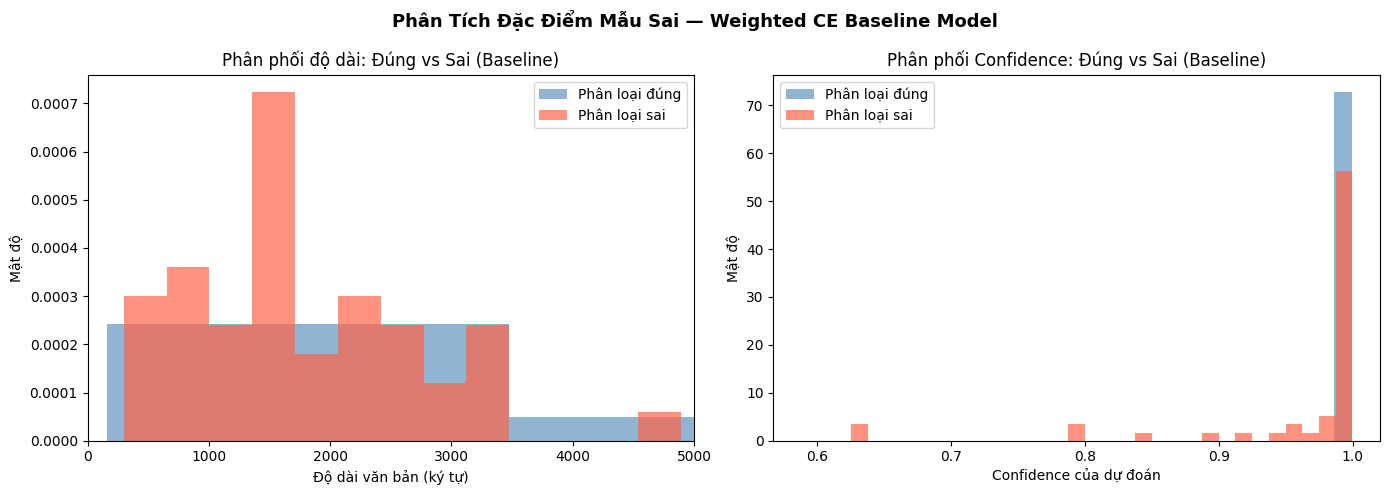


📊 Thống kê độ dài:
  Mẫu đúng — Trung bình: 2412 | Trung vị: 1944 ký tự
  Mẫu sai  — Trung bình: 2089   | Trung vị: 1654 ký tự

📊 Thống kê confidence:
  Mẫu đúng — TB confidence: 0.999
  Mẫu sai  — TB confidence: 0.963


In [ ]:
# ── Phân tích đặc điểm các mẫu sai: Weighted CE (Baseline) ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Độ dài (số ký tự) của mẫu đúng và mẫu sai
correct_mask_baseline = ~error_mask_baseline
len_error_baseline   = [len(t) for t in error_texts_baseline]
len_correct_baseline = [len(X_test_texts[i]) for i in range(len(y_test)) if correct_mask_baseline[i]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phân phối độ dài
axes[0].hist(len_correct_baseline, bins=50, alpha=0.6, label='Phân loại đúng', color='steelblue', density=True)
axes[0].hist(len_error_baseline,   bins=50, alpha=0.7, label='Phân loại sai',  color='tomato',    density=True)
axes[0].set_xlabel('Độ dài văn bản (ký tự)')
axes[0].set_ylabel('Mật độ')
axes[0].set_title('Phân phối độ dài: Đúng vs Sai (Baseline)')
axes[0].legend()
axes[0].set_xlim(0, 5000)

# Biểu đồ 2: Confidence distribution của mẫu sai
import torch, torch.nn.functional as TF
all_probs_baseline = TF.softmax(torch.tensor(preds_baseline.predictions), dim=1).numpy()
conf_correct_baseline = [all_probs_baseline[i][y_pred_baseline[i]] for i in range(len(y_test)) if not error_mask_baseline[i]]
conf_error_baseline   = [all_probs_baseline[i][y_pred_baseline[i]] for i in range(len(y_test)) if error_mask_baseline[i]]

axes[1].hist(conf_correct_baseline, bins=30, alpha=0.6, label='Phân loại đúng', color='steelblue', density=True)
axes[1].hist(conf_error_baseline,   bins=30, alpha=0.7, label='Phân loại sai',  color='tomato',    density=True)
axes[1].set_xlabel('Confidence của dự đoán')
axes[1].set_ylabel('Mật độ')
axes[1].set_title('Phân phối Confidence: Đúng vs Sai (Baseline)')
axes[1].legend()

plt.suptitle('Phân Tích Đặc Điểm Mẫu Sai — Weighted CE Baseline Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Thống kê tóm tắt
print(f"\n📊 Thống kê độ dài:")
print(f"  Mẫu đúng — Trung bình: {np.mean(len_correct_baseline):.0f} | Trung vị: {np.median(len_correct_baseline):.0f} ký tự")
print(f"  Mẫu sai  — Trung bình: {np.mean(len_error_baseline):.0f}   | Trung vị: {np.median(len_error_baseline):.0f} ký tự")
print(f"\n📊 Thống kê confidence:")
print(f"  Mẫu đúng — TB confidence: {np.mean(conf_correct_baseline):.3f}")
print(f"  Mẫu sai  — TB confidence: {np.mean(conf_error_baseline):.3f}")

### 4.3 — Phân Tích Lỗi Chuyên Sâu

Phần này trích xuất và phân tích các mẫu bị phân loại sai nhằm hiểu giới hạn của mô hình.


In [ ]:
# ── Phân tích lỗi: Focal Loss model (mô hình chính) ─────────────────────────
X_test_texts = list(X_test)

# Tìm các mẫu sai
error_mask = y_pred_focal != y_test
error_texts  = [X_test_texts[i] for i in range(len(y_test)) if error_mask[i]]
error_true   = [y_test[i]       for i in range(len(y_test)) if error_mask[i]]
error_pred   = [y_pred_focal[i] for i in range(len(y_test)) if error_mask[i]]
error_probs  = preds_focal.predictions[error_mask]

label_name = {0: 'Tin thật', 1: 'Tin giả'}

print(f"📌 Tổng mẫu sai (Focal Loss): {sum(error_mask)} / {len(y_test)}")
print(f"   • False Negative (Tin giả → dự đoán Thật): {sum(1 for t,p in zip(error_true, error_pred) if t==1 and p==0)}")
print(f"   • False Positive (Tin thật → dự đoán Giả):  {sum(1 for t,p in zip(error_true, error_pred) if t==0 and p==1)}")

# ── Phân tích chi tiết 10 mẫu sai ───────────────────────────────────────────
import torch.nn.functional as TF
import torch

print("\n" + "=" * 70)
print("CHI TIẾT 10 MẪU BỊ PHÂN LOẠI SAI (Focal Loss)")
print("=" * 70)

for i in range(min(10, len(error_texts))):
    probs = TF.softmax(torch.tensor(error_probs[i]), dim=0).numpy()
    conf  = probs[error_pred[i]]
    text_preview = error_texts[i][:200].replace('\n', ' ')
    err_type = 'FALSE NEGATIVE' if error_true[i]==1 else 'FALSE POSITIVE'

    print(f"\n[{i+1}] {err_type}")
    print(f"  Nhãn thật : {label_name[error_true[i]]}")
    print(f"  Dự đoán   : {label_name[error_pred[i]]} (confidence: {conf:.2%})")
    print(f"  Xác suất  : Thật={probs[0]:.3f} | Giả={probs[1]:.3f}")
    print(f"  Nội dung  : {text_preview}...")


📌 Tổng mẫu sai (Focal Loss): 67 / 8137
   • False Negative (Tin giả → dự đoán Thật): 55
   • False Positive (Tin thật → dự đoán Giả):  12

CHI TIẾT 10 MẪU BỊ PHÂN LOẠI SAI (Focal Loss)

[1] FALSE NEGATIVE
  Nhãn thật : Tin giả
  Dự đoán   : Tin thật (confidence: 78.91%)
  Xác suất  : Thật=0.789 | Giả=0.211
  Nội dung  : tập_đoàn brg liên_tiếp vinh_danh giải_thưởng bci asia awards 2022 góp_mặt giải_thưởng danh_giá liên_tiếp công_nhận tôn_vinh cộng_đồng quốc_tế góp_phần khẳng_định_vị_thế tập_đoàn brg lĩnh_vực xây_dựng ...

[2] FALSE POSITIVE
  Nhãn thật : Tin thật
  Dự đoán   : Tin giả (confidence: 64.02%)
  Xác suất  : Thật=0.360 | Giả=0.640
  Nội dung  : dứa tác_dụng tích_cực dứa thường_xuyên tiêu_hóa khả_năng đau cải_thiện sức_khỏe mạch_máu cải_thiện tiêu_hóa nghiên_cứu khoa_học bồ đào nha ép dứa gia_tăng probiotic vi_khuẩn lợi đường ruột tiêu_hóa sứ...

[3] FALSE NEGATIVE
  Nhãn thật : Tin giả
  Dự đoán   : Tin thật (confidence: 65.84%)
  Xác suất  : Thật=0.658 | Giả=0.342
  Nội dung

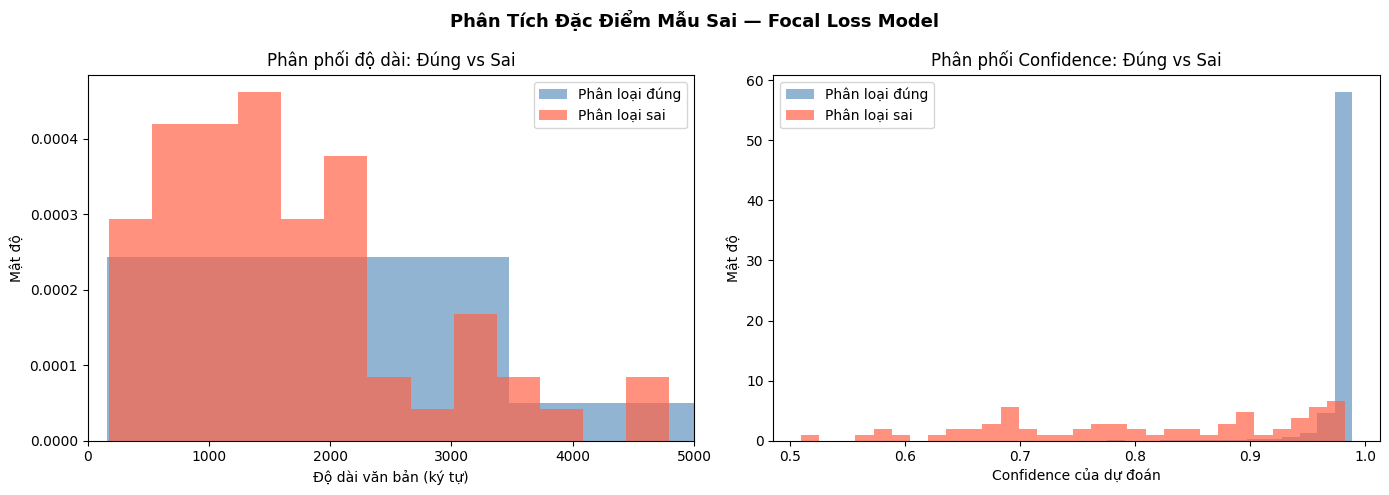


📊 Thống kê độ dài:
  Mẫu đúng — Trung bình: 2414 | Trung vị: 1947 ký tự
  Mẫu sai  — Trung bình: 1883   | Trung vị: 1441 ký tự

📊 Thống kê confidence:
  Mẫu đúng — TB confidence: 0.979
  Mẫu sai  — TB confidence: 0.808


In [ ]:
# ── Phân tích đặc điểm các mẫu sai ─────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

# Độ dài (số ký tự) của mẫu đúng và mẫu sai
correct_mask = ~error_mask
len_error   = [len(t) for t in error_texts]
len_correct = [len(X_test_texts[i]) for i in range(len(y_test)) if correct_mask[i]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phân phối độ dài
axes[0].hist(len_correct, bins=50, alpha=0.6, label='Phân loại đúng', color='steelblue', density=True)
axes[0].hist(len_error,   bins=50, alpha=0.7, label='Phân loại sai',  color='tomato',    density=True)
axes[0].set_xlabel('Độ dài văn bản (ký tự)')
axes[0].set_ylabel('Mật độ')
axes[0].set_title('Phân phối độ dài: Đúng vs Sai')
axes[0].legend()
axes[0].set_xlim(0, 5000)

# Biểu đồ 2: Confidence distribution của mẫu sai
import torch, torch.nn.functional as TF
all_probs = TF.softmax(torch.tensor(preds_focal.predictions), dim=1).numpy()
conf_correct = [all_probs[i][y_pred_focal[i]] for i in range(len(y_test)) if not error_mask[i]]
conf_error   = [all_probs[i][y_pred_focal[i]] for i in range(len(y_test)) if error_mask[i]]

axes[1].hist(conf_correct, bins=30, alpha=0.6, label='Phân loại đúng', color='steelblue', density=True)
axes[1].hist(conf_error,   bins=30, alpha=0.7, label='Phân loại sai',  color='tomato',    density=True)
axes[1].set_xlabel('Confidence của dự đoán')
axes[1].set_ylabel('Mật độ')
axes[1].set_title('Phân phối Confidence: Đúng vs Sai')
axes[1].legend()

plt.suptitle('Phân Tích Đặc Điểm Mẫu Sai — Focal Loss Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Thống kê tóm tắt
print(f"\n📊 Thống kê độ dài:")
print(f"  Mẫu đúng — Trung bình: {np.mean(len_correct):.0f} | Trung vị: {np.median(len_correct):.0f} ký tự")
print(f"  Mẫu sai  — Trung bình: {np.mean(len_error):.0f}   | Trung vị: {np.median(len_error):.0f} ký tự")
print(f"\n📊 Thống kê confidence:")
print(f"  Mẫu đúng — TB confidence: {np.mean(conf_correct):.3f}")
print(f"  Mẫu sai  — TB confidence: {np.mean(conf_error):.3f}")


In [ ]:
import pandas as pd
import torch.nn.functional as TF
import torch

# Khởi tạo danh sách để lưu trữ dữ liệu lỗi
error_data_focal = []
error_data_baseline = []

label_name = {0: 'Tin thật', 1: 'Tin giả'}

# --- Dữ liệu lỗi từ mô hình Focal Loss ---
# error_texts, error_true, error_pred, error_probs đã được tạo ở cell trước
for i in range(len(error_texts)):
    probs_tensor = TF.softmax(torch.tensor(error_probs[i]), dim=0).numpy()
    conf = probs_tensor[error_pred[i]]
    error_data_focal.append({
        'Nhãn Thật': label_name[error_true[i]],
        'Dự Đoán': label_name[error_pred[i]],
        'Xác Suất Dự Đoán': f"{conf:.3f}",
        'Nội Dung': error_texts[i],
        'Mô Hình': 'Focal Loss'
    })

# --- Dữ liệu lỗi từ mô hình Weighted CE (Baseline) ---
# error_texts_baseline, error_true_baseline, error_pred_baseline, error_probs_baseline đã được tạo ở cell trước
for i in range(len(error_texts_baseline)):
    probs_tensor_baseline = TF.softmax(torch.tensor(error_probs_baseline[i]), dim=0).numpy()
    conf_baseline = probs_tensor_baseline[error_pred_baseline[i]]
    error_data_baseline.append({
        'Nhãn Thật': label_name[error_true_baseline[i]],
        'Dự Đoán': label_name[error_pred_baseline[i]],
        'Xác Suất Dự Đoán': f"{conf_baseline:.3f}",
        'Nội Dung': error_texts_baseline[i],
        'Mô Hình': 'Weighted CE'
    })

# Tạo DataFrame từ dữ liệu lỗi
df_errors_focal = pd.DataFrame(error_data_focal)
df_errors_baseline = pd.DataFrame(error_data_baseline)

# Kết hợp hai DataFrame
df_all_errors = pd.concat([df_errors_focal, df_errors_baseline], ignore_index=True)

# Lưu ra file Excel
excel_output_path = '/content/phan_tich_loi_fakenews.xlsx'
df_all_errors.to_excel(excel_output_path, index=False)

print(f"✅ Đã tạo file Excel phân tích lỗi tại: {excel_output_path}")
print(f"Tổng số mẫu lỗi đã lưu: {len(df_all_errors)}")

✅ Đã tạo file Excel phân tích lỗi tại: /content/phan_tich_loi_fakenews.xlsx
Tổng số mẫu lỗi đã lưu: 114
